In [2]:
import numpy as np

In [3]:
# =====================================================
# CONFIGURATION
# =====================================================

HISTORY = 12
LEAD = 6

TARGET_LAT_MIN = 18
TARGET_LAT_MAX = 18.5

TARGET_LON_MIN = 73.5
TARGET_LON_MAX = 74.5

In [4]:
# =====================================================
# LOAD DATA
# =====================================================

data = np.load("Dataset/rainvision_dataset_merged_2016_2025.npz", allow_pickle=True)

X = data["X"]
y = data["y"]

feature_names = list(data["feature_names"])

latitudes = data["latitudes"]
longitudes = data["longitudes"]

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

print("\nOriginal Features:")
print(feature_names)

Original X shape: (61368, 29, 33, 11)
Original y shape: (61368, 29, 33)

Original Features:
['cape', 'z', 'sp', 'tcwv', 'msl', 'blh', 'tcc', 'u10', 'v10', 't2m', 'd2m']


In [5]:
# =====================================================
# REMOVE GEOPOTENTIAL IF PRESENT
# =====================================================

if "z" in feature_names:
    z_idx = feature_names.index("z")

    X = np.delete(X, z_idx, axis=-1)
    feature_names.pop(z_idx)

In [6]:
# =====================================================
# GET FEATURE INDICES
# =====================================================

u_idx = feature_names.index("u10")
v_idx = feature_names.index("v10")

tcwv_idx = feature_names.index("tcwv")

t2m_idx = feature_names.index("t2m")
d2m_idx = feature_names.index("d2m")

# =====================================================
# EXTRACT BASE VARIABLES
# =====================================================

u10 = X[..., u_idx]
v10 = X[..., v_idx]

tcwv = X[..., tcwv_idx]

t2m = X[..., t2m_idx]
d2m = X[..., d2m_idx]

# =====================================================
# 1. WIND SPEED
# =====================================================

wind_speed = np.sqrt(u10**2 + v10**2)

# =====================================================
# 2. WIND DIRECTION radians [-pi, pi]
# =====================================================

wind_direction = np.arctan2(v10, u10)

wind_dir_sin = np.sin(wind_direction)
wind_dir_cos = np.cos(wind_direction)
# =====================================================
# 3. DEW POINT DEPRESSION
# =====================================================

dewpoint_depression = t2m - d2m

# =====================================================
# 4. MOISTURE FLUX
# =====================================================
#
# Proxy:
#
# Flux_u = TCWV * U10
# Flux_v = TCWV * V10
#
# =====================================================

moisture_flux_u = tcwv * u10
moisture_flux_v = tcwv * v10

# =====================================================
# 5. MOISTURE FLUX MAGNITUDE
# =====================================================

moisture_flux_mag = np.sqrt(
    moisture_flux_u**2 +
    moisture_flux_v**2
)

# =====================================================
# 6. IMPROVED MOISTURE FLUX CONVERGENCE / DIVERGENCE
# =====================================================

R = 6371000.0

lat_rad = np.deg2rad(latitudes)

dlat = np.deg2rad(np.mean(np.diff(latitudes)))

dlon = np.deg2rad(np.mean(np.diff(longitudes)))

dy = R * dlat

dx = (R * np.cos(lat_rad) * dlon)

dx = dx.reshape(-1, 1)

raw_dFu_dx = np.gradient(
    moisture_flux_u,
    axis=2
)

raw_dFv_dy = np.gradient(
    moisture_flux_v,
    axis=1
)

dFu_dx = raw_dFu_dx / dx[None,:,:]

dFv_dy = raw_dFv_dy / dy

moisture_flux_divergence = (dFu_dx + dFv_dy)

moisture_flux_convergence = (-moisture_flux_divergence)

# =====================================================
# 6. MOISTURE RESIDENCE PROXY
# =====================================================

moisture_residence_proxy = (tcwv * moisture_flux_mag)

In [7]:
new_features = np.stack(
    [
        wind_speed,
        wind_dir_sin,
        wind_dir_cos,
        dewpoint_depression,
        moisture_flux_u,
        moisture_flux_v,
        moisture_flux_mag,
        moisture_flux_convergence,
        moisture_flux_divergence,
        moisture_residence_proxy
    ],
    axis=-1
)

new_feature_names = [
    "wind_speed",
    "wind_dir_sin",
    "wind_dir_cos",
    "dewpoint_depression",
    "moisture_flux_u",
    "moisture_flux_v",
    "moisture_flux_mag",
    "moisture_flux_convergence",
    "moisture_flux_divergence",
    "moisture_residence_proxy"
]

# =====================================================
# APPEND TO ORIGINAL FEATURE SET
# =====================================================

X = np.concatenate(
    [X, new_features],
    axis=-1
)

feature_names.extend(new_feature_names)

# =====================================================
# FINAL SUMMARY
# =====================================================

print("\nEnhanced X shape:", X.shape)

print("\nFeatures After Engineering:")
for f in feature_names:
    print(f)

print("\nTotal Features =", len(feature_names))


Enhanced X shape: (61368, 29, 33, 20)

Features After Engineering:
cape
sp
tcwv
msl
blh
tcc
u10
v10
t2m
d2m
wind_speed
wind_dir_sin
wind_dir_cos
dewpoint_depression
moisture_flux_u
moisture_flux_v
moisture_flux_mag
moisture_flux_convergence
moisture_flux_divergence
moisture_residence_proxy

Total Features = 20


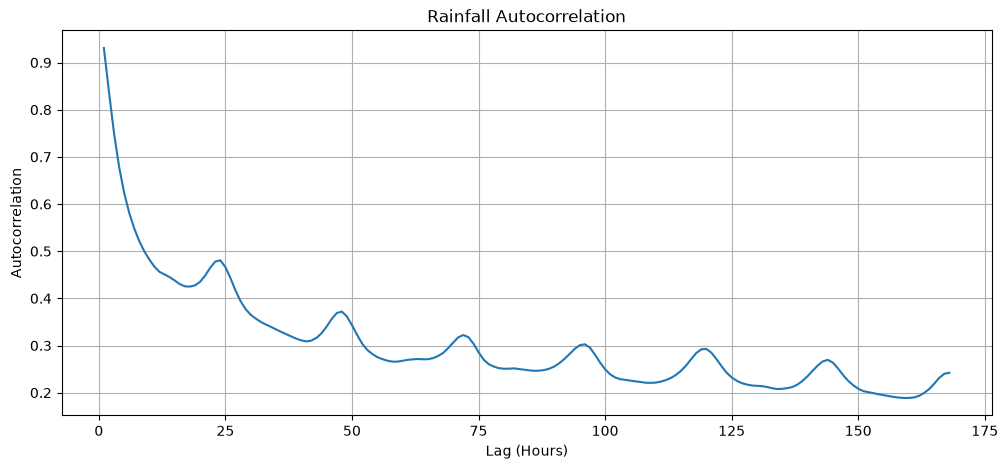

In [8]:
import matplotlib.pyplot as plt

# ==========================================
# TARGET REGION
# ==========================================

lat_mask = (
    (latitudes >= TARGET_LAT_MIN) &
    (latitudes <= TARGET_LAT_MAX)
)

lon_mask = (
    (longitudes >= TARGET_LON_MIN) &
    (longitudes <= TARGET_LON_MAX)
)

y_small = y[:, lat_mask][:, :, lon_mask]

# ==========================================
# REGION AVERAGE RAINFALL
# ==========================================

rain_ts = y_small.mean(axis=(1,2))

# ==========================================
# AUTOCORRELATION
# ==========================================

max_lag = 24 * 7

autocorrs = []

for lag in range(1, max_lag + 1):

    r = np.corrcoef(
        rain_ts[:-lag],
        rain_ts[lag:]
    )[0,1]

    autocorrs.append(r)

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(12,5))
plt.plot(range(1,max_lag+1), autocorrs)

plt.xlabel("Lag (Hours)")
plt.ylabel("Autocorrelation")
plt.title("Rainfall Autocorrelation")

plt.grid(True)

plt.show()

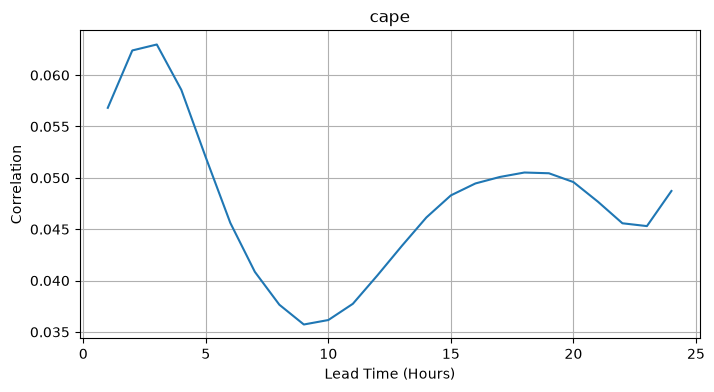

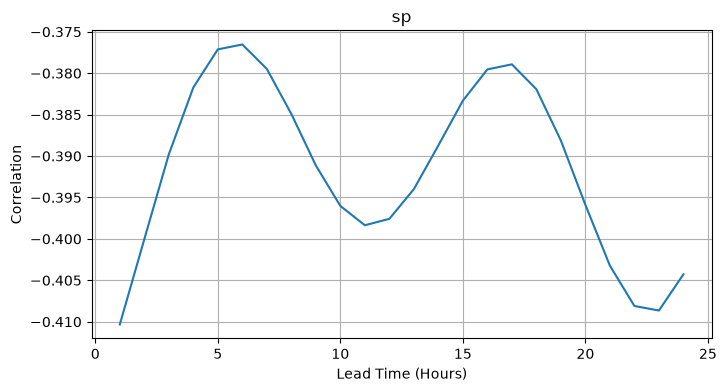

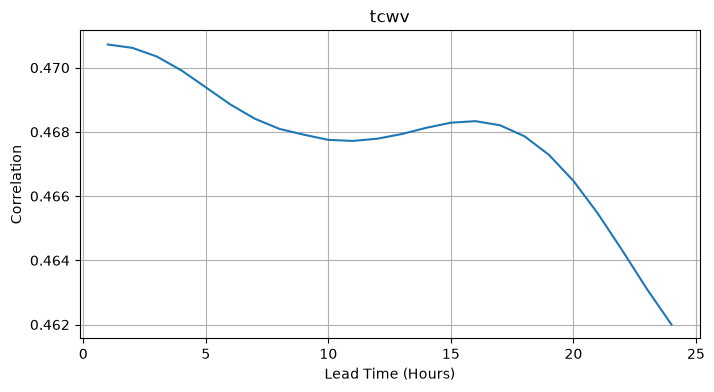

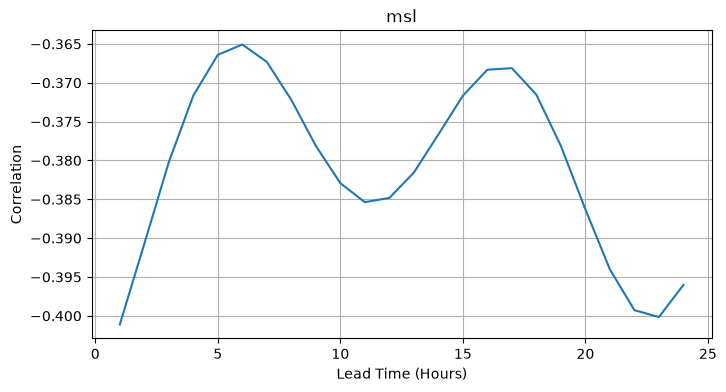

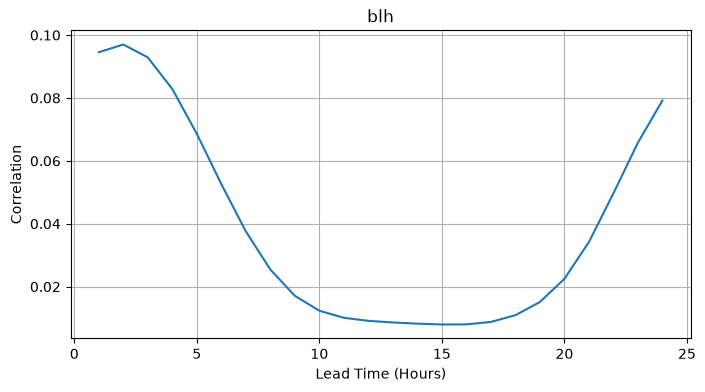

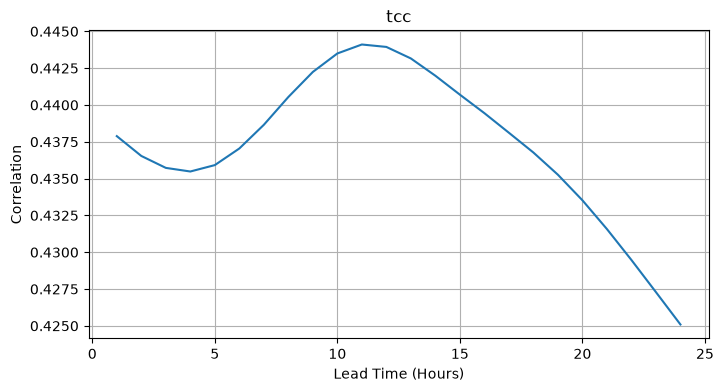

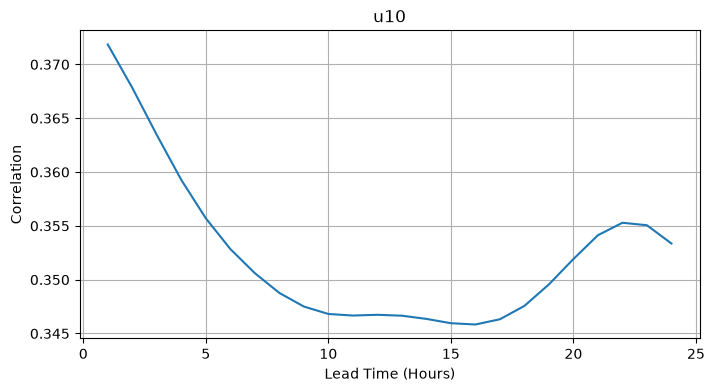

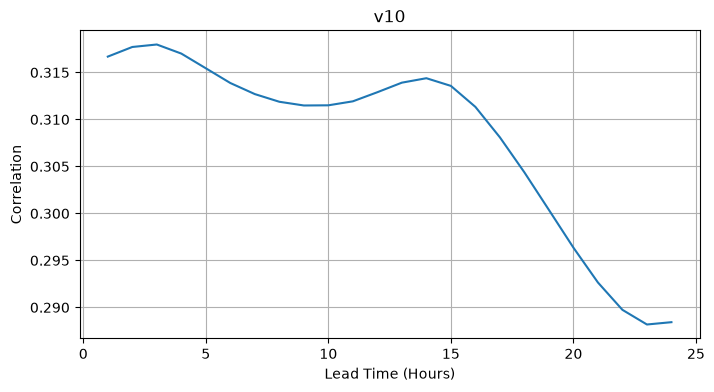

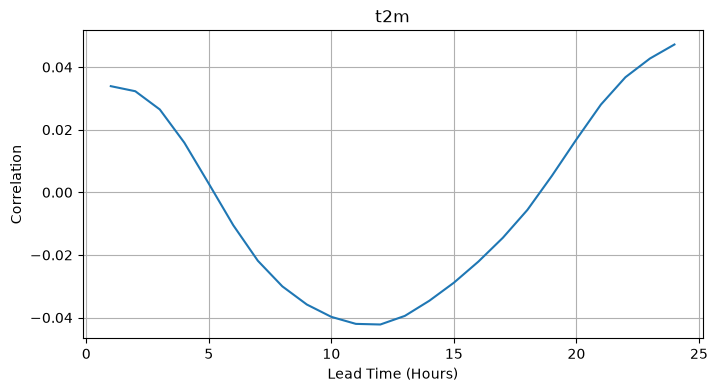

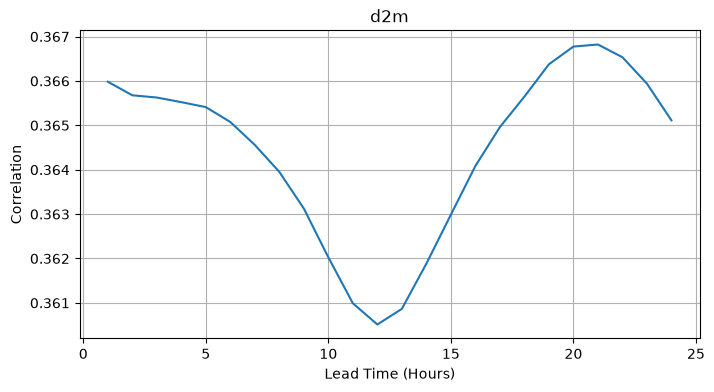

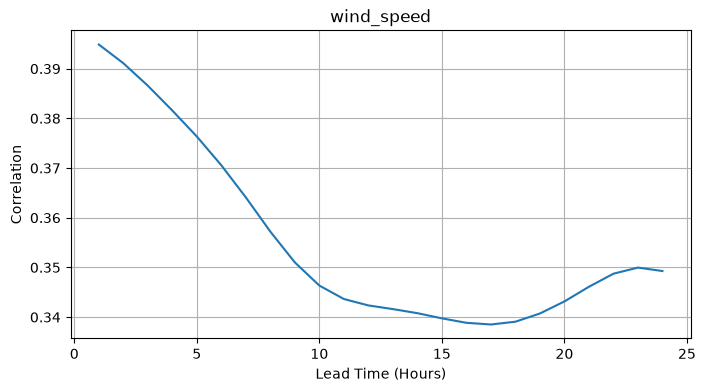

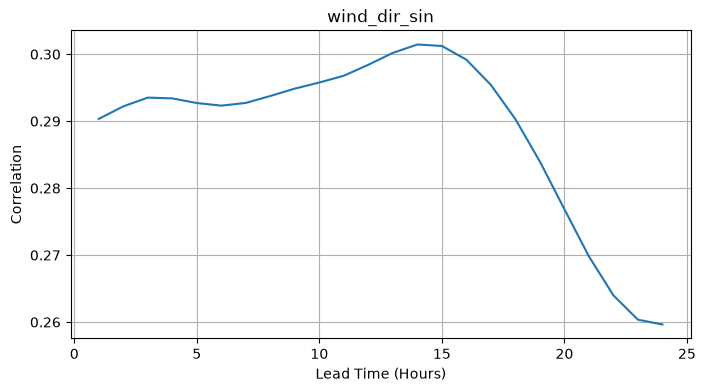

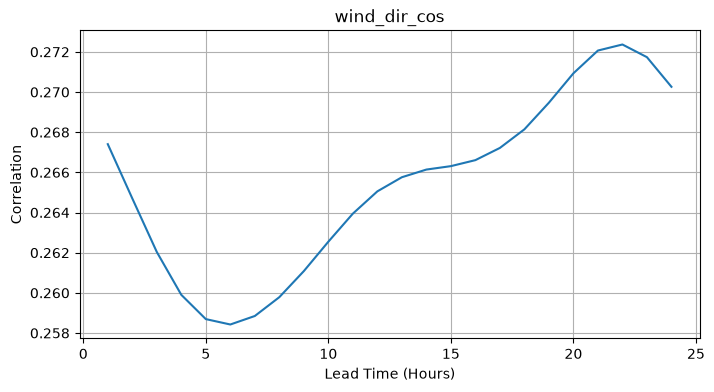

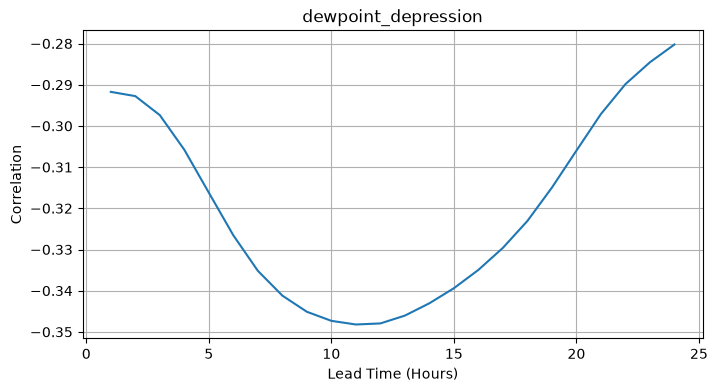

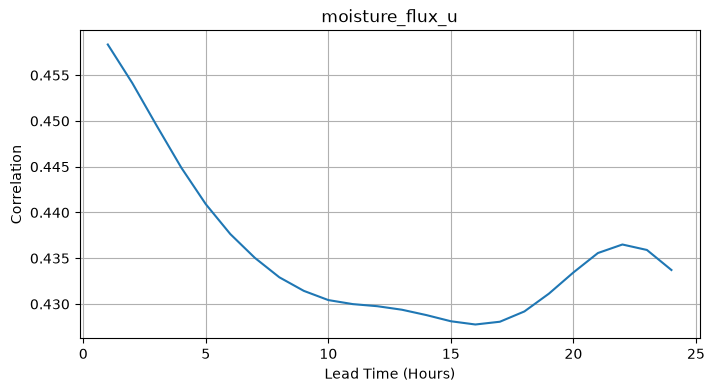

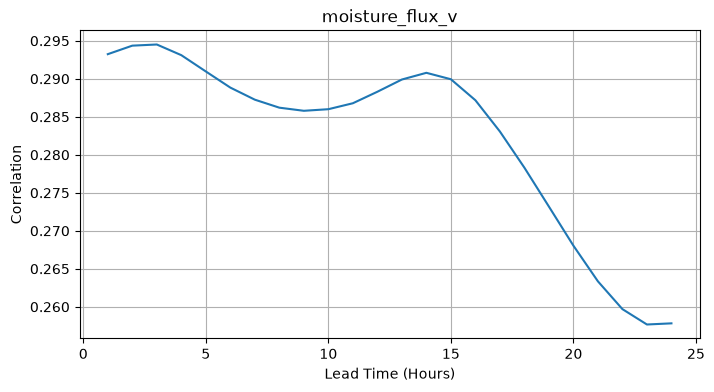

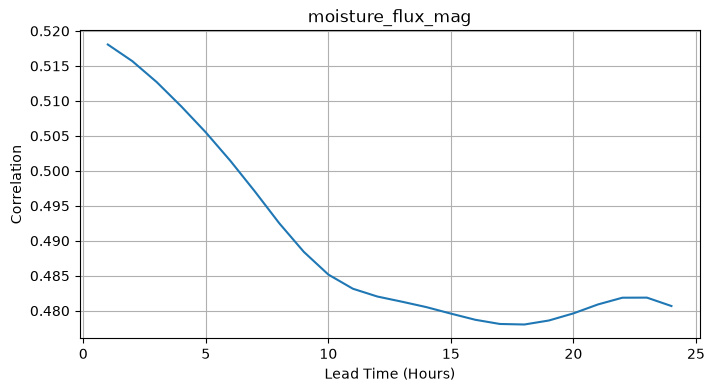

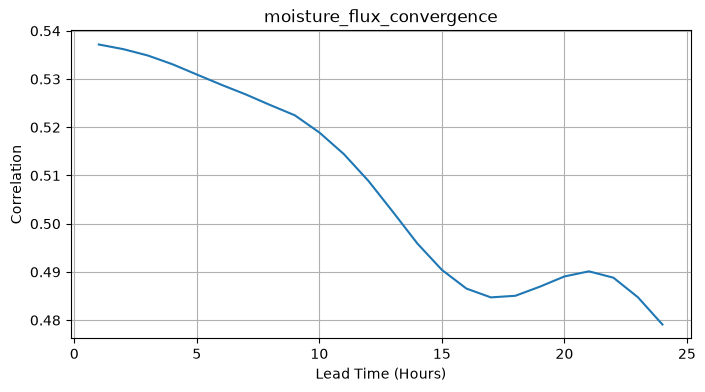

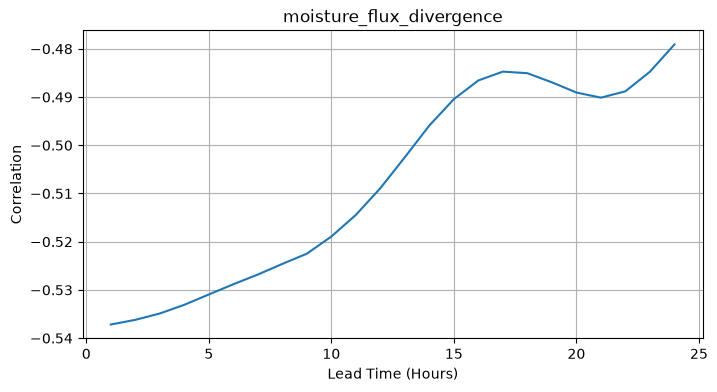

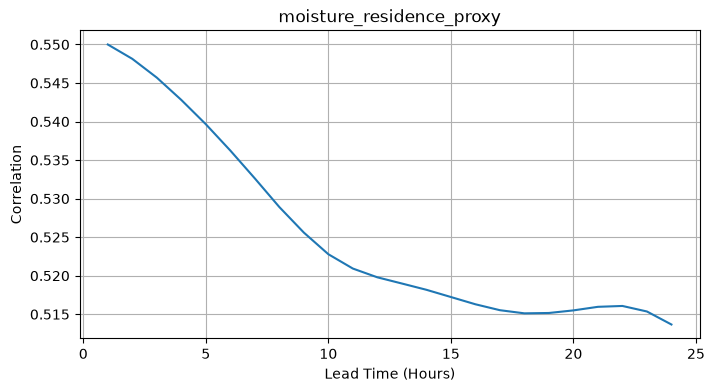

In [9]:
# ==========================================
# REGION AVERAGE RAIN
# ==========================================

rain_ts = y_small.mean(axis=(1,2))

# ==========================================
# FEATURE NAMES
# ==========================================

for feature_idx, feature_name in enumerate(feature_names):

    feature_ts = X[..., feature_idx].mean(axis=(1,2))

    correlations = []

    for lag in range(1,25):

        corr = np.corrcoef(
            feature_ts[:-lag],
            rain_ts[lag:]
        )[0,1]

        correlations.append(corr)

    plt.figure(figsize=(8,4))

    plt.plot(range(1,25), correlations)

    plt.title(feature_name)
    plt.xlabel("Lead Time (Hours)")
    plt.ylabel("Correlation")

    plt.grid(True)

    plt.show()

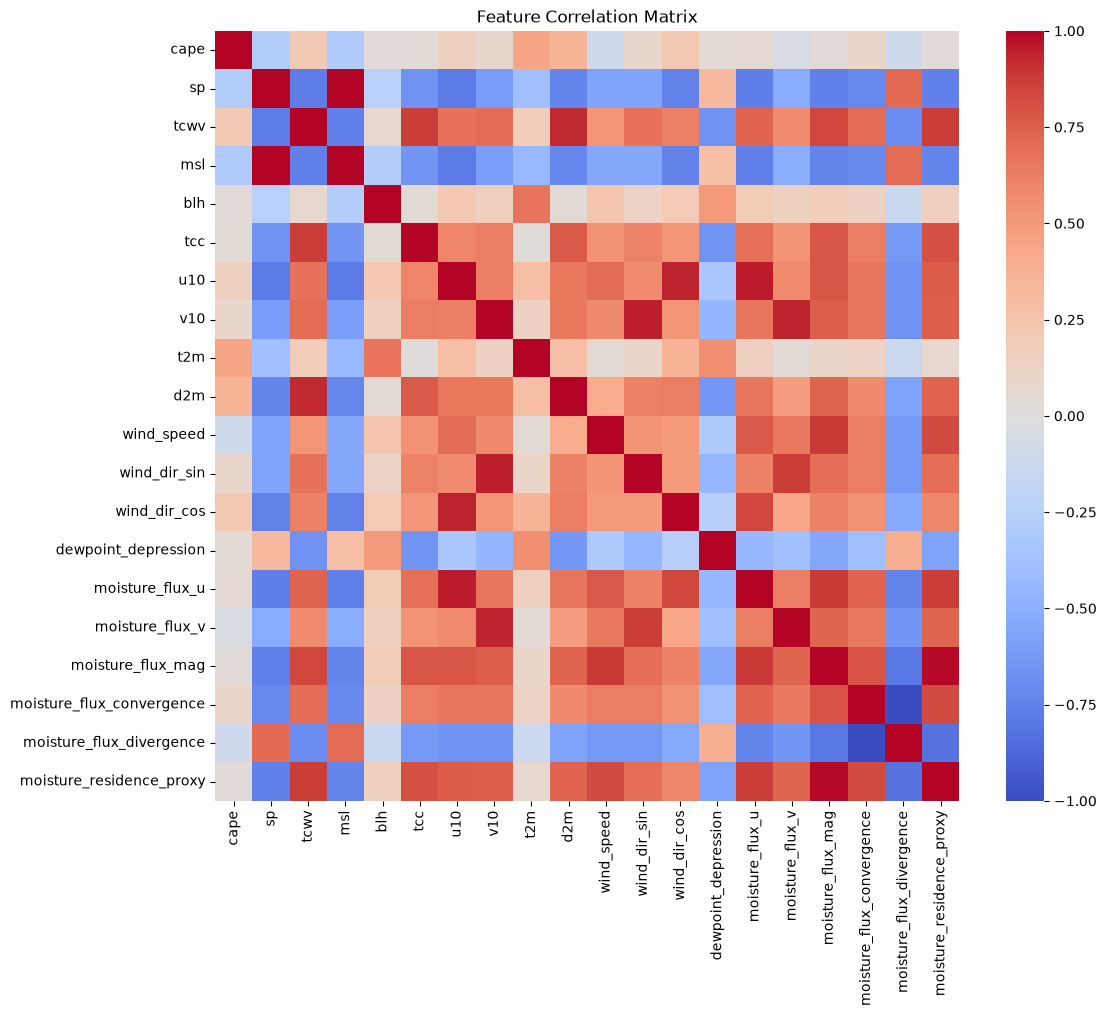

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# SPATIAL-TEMPORAL MEAN
# ==========================================

feature_series = []

for i in range(len(feature_names)):

    ts = X[...,i].mean(axis=(1,2))
    feature_series.append(ts)

feature_series = np.array(feature_series)

# ==========================================
# CORRELATION MATRIX
# ==========================================

corr_matrix = np.corrcoef(feature_series)

corr_df = pd.DataFrame(
    corr_matrix,
    index=feature_names,
    columns=feature_names
)

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_df,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [11]:
from sklearn.feature_selection import mutual_info_regression

# ==========================================
# TARGET
# ==========================================

rain_ts = y_small.mean(axis=(1,2))

# ==========================================
# FEATURE SERIES
# ==========================================

feature_matrix = []

for i in range(len(feature_names)):

    ts = X[...,i].mean(axis=(1,2))
    feature_matrix.append(ts)

feature_matrix = np.array(feature_matrix).T

# ==========================================
# 6-HOUR LEAD TARGET
# ==========================================

lead = 6

X_mi = feature_matrix[:-lead]
y_mi = rain_ts[lead:]

# ==========================================
# MI
# ==========================================

mi_scores = mutual_info_regression(
    X_mi,
    y_mi,
    random_state=42
)

# ==========================================
# SORT
# ==========================================

ranking = sorted(
    zip(feature_names, mi_scores),
    key=lambda x: x[1],
    reverse=True
)

print("\nFeature Importance (Mutual Information)\n")

for feature, score in ranking:
    print(f"{feature:30s} {score:.4f}")


Feature Importance (Mutual Information)

tcwv                           0.5838
moisture_residence_proxy       0.5700
moisture_flux_mag              0.5054
d2m                            0.4885
moisture_flux_u                0.4563
tcc                            0.4379
moisture_flux_divergence       0.3273
moisture_flux_convergence      0.3273
dewpoint_depression            0.3137
u10                            0.3072
v10                            0.2896
moisture_flux_v                0.2801
sp                             0.2634
wind_dir_cos                   0.2539
msl                            0.2509
wind_dir_sin                   0.2501
wind_speed                     0.2413
blh                            0.2299
cape                           0.1734
t2m                            0.1470


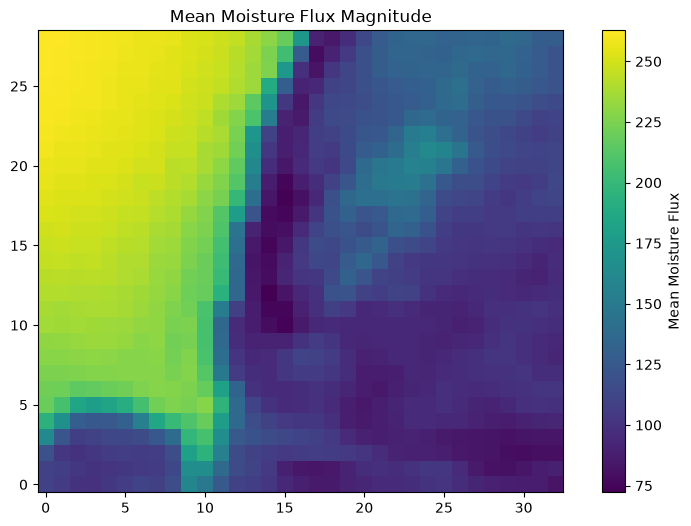

In [12]:
rain_mean = y.mean(axis=0)

mflux_mean = moisture_flux_mag.mean(axis=0)

plt.figure(figsize=(10,6))

plt.imshow(
    mflux_mean,
    origin="lower",
    cmap="viridis"
)

plt.colorbar(label="Mean Moisture Flux")

plt.title("Mean Moisture Flux Magnitude")

plt.show()

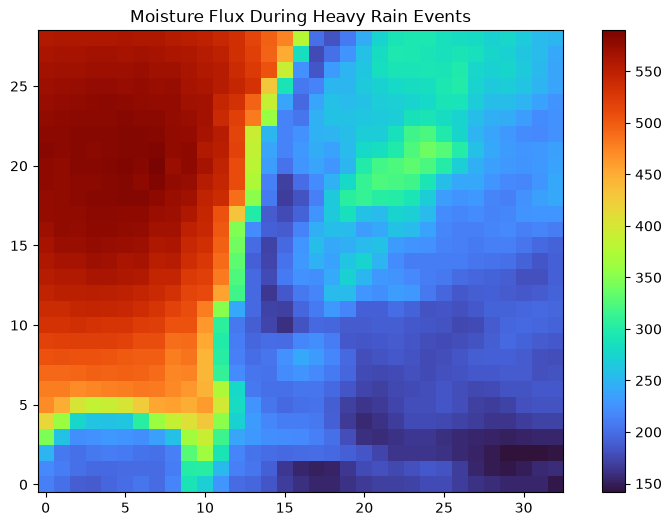

In [13]:
import numpy as np
import matplotlib.pyplot as plt

rain_region = y_small.mean(axis=(1,2))

threshold = np.percentile(
    rain_region,
    95
)

heavy_idx = np.where(
    rain_region >= threshold
)[0]

composite_flux = moisture_flux_mag[
    heavy_idx
].mean(axis=0)

plt.figure(figsize=(10,6))

plt.imshow(
    composite_flux,
    origin="lower",
    cmap="turbo"
)

plt.colorbar()

plt.title(
    "Moisture Flux During Heavy Rain Events"
)

plt.show()

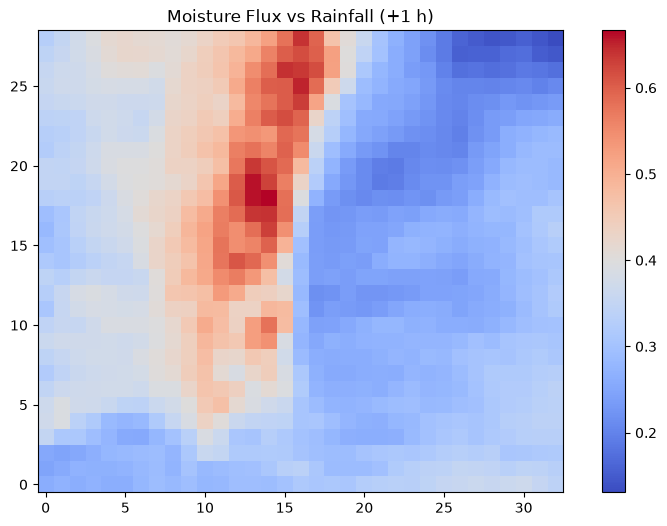

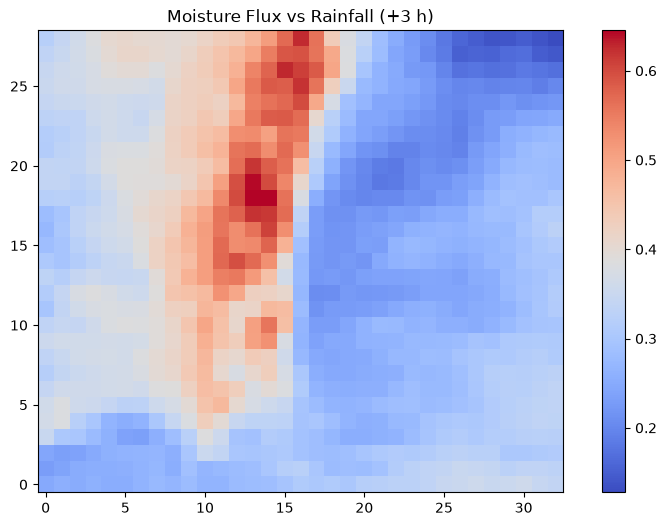

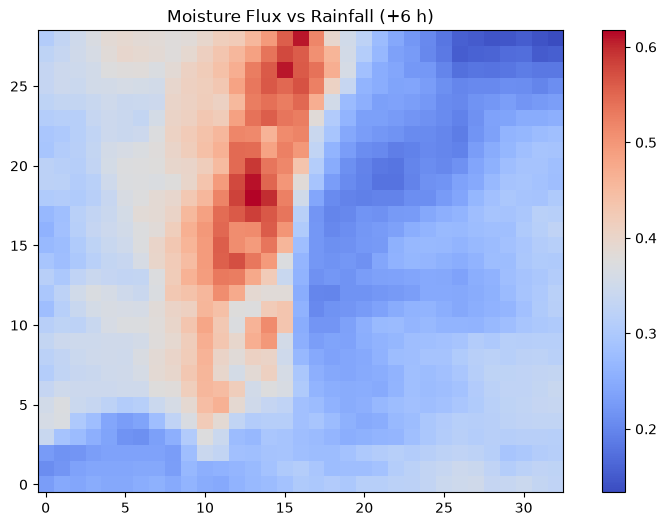

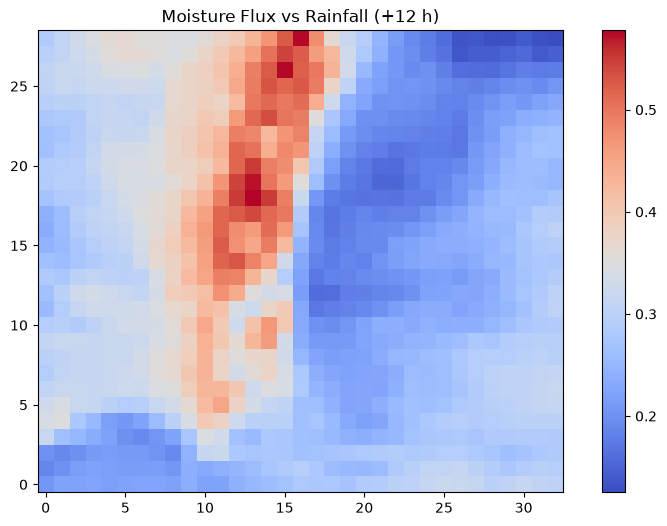

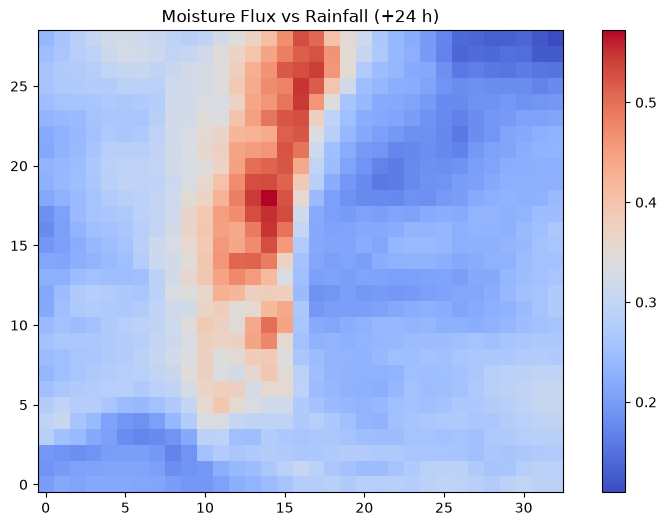

In [28]:
import numpy as np
import matplotlib.pyplot as plt

lead_hours = [1,3,6,12,24]

for lead in lead_hours:

    corr_map = np.zeros(
        (
            X.shape[1],
            X.shape[2]
        )
    )

    for i in range(X.shape[1]):
        for j in range(X.shape[2]):

            corr_map[i,j] = np.corrcoef(
                moisture_flux_mag[:-lead,i,j],
                y[lead:,i,j]
            )[0,1]

    plt.figure(figsize=(10,6))

    plt.imshow(
        corr_map,
        origin="lower",
        cmap="coolwarm"
    )

    plt.colorbar()

    plt.title(
        f"Moisture Flux vs Rainfall (+{lead} h)"
    )

    plt.show()

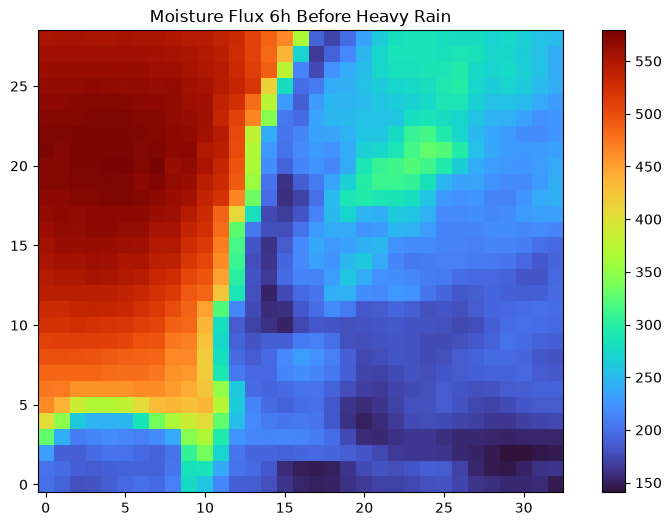

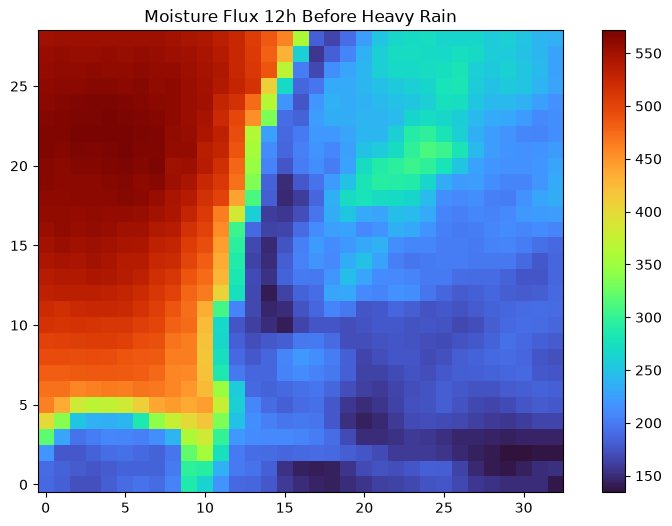

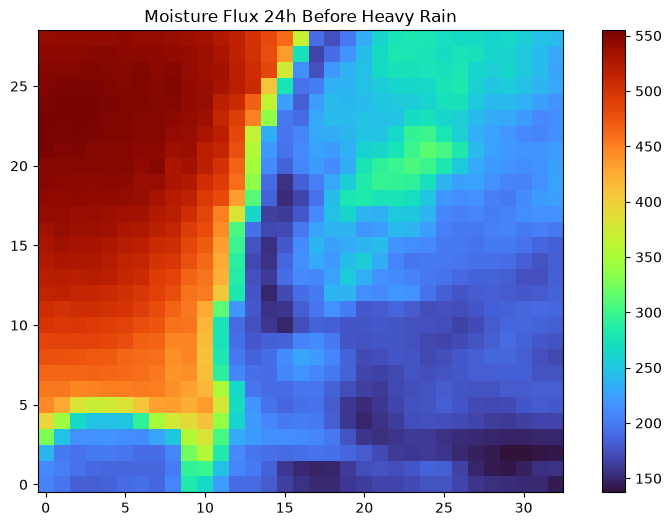

In [15]:
lags = [6,12,24]

rain_region = y_small.mean(axis=(1,2))

heavy_threshold = np.percentile(
    rain_region,
    95
)

heavy_events = np.where(
    rain_region >= heavy_threshold
)[0]

for lag in lags:

    valid = heavy_events[
        heavy_events > lag
    ]

    composite = moisture_flux_mag[
        valid - lag
    ].mean(axis=0)

    plt.figure(figsize=(10,6))

    plt.imshow(
        composite,
        origin="lower",
        cmap="turbo"
    )

    plt.colorbar()

    plt.title(
        f"Moisture Flux {lag}h Before Heavy Rain"
    )

    plt.show()

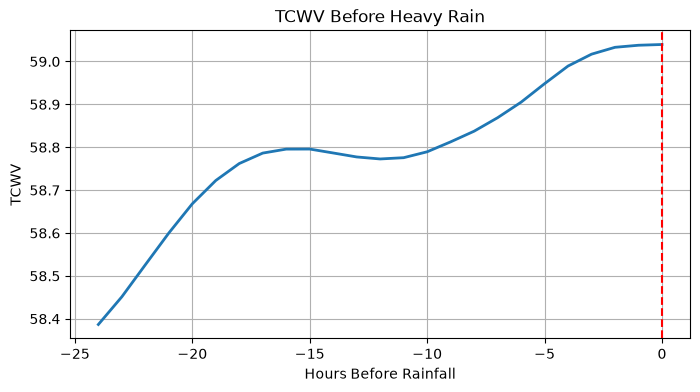

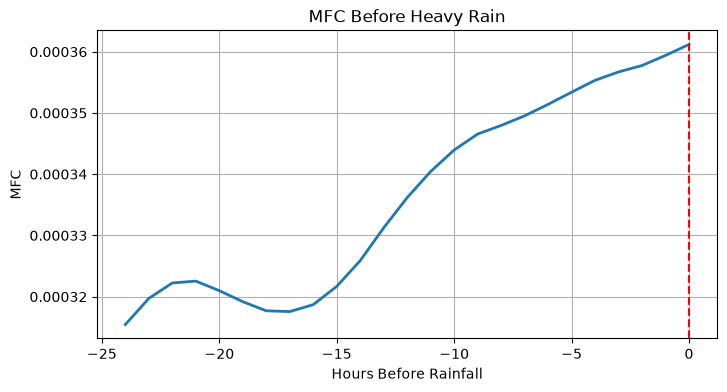

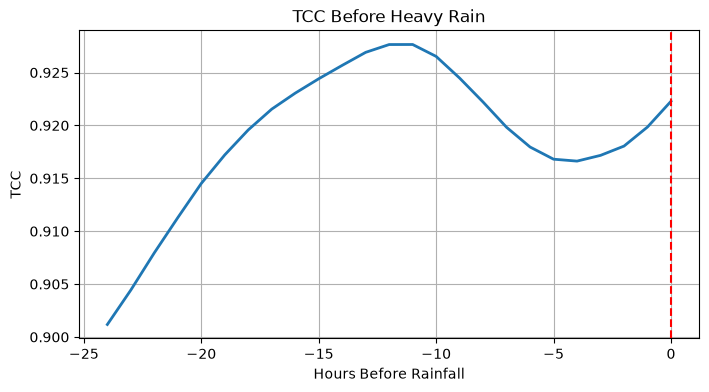

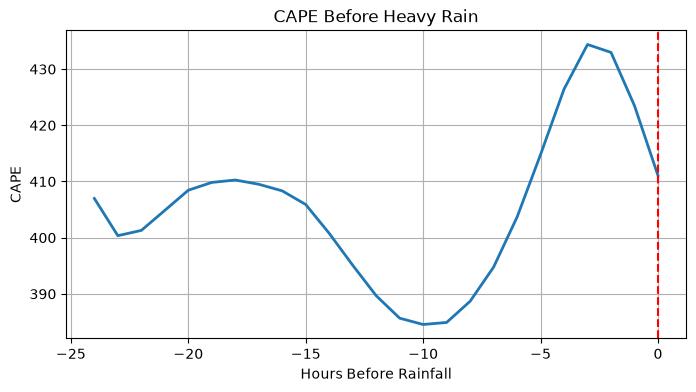

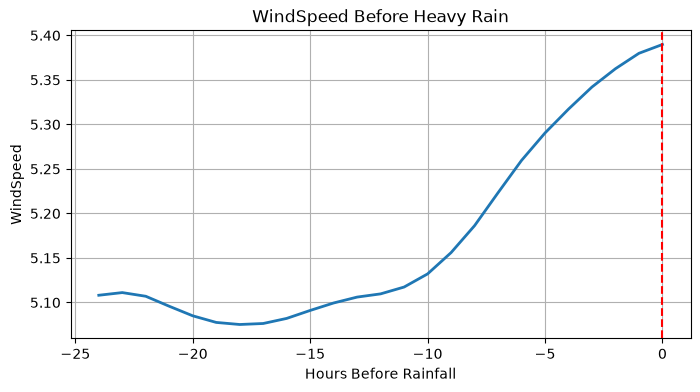

In [16]:
# =====================================================
# TEST 6 : HEAVY RAIN COMPOSITE EVOLUTION
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

rain_region = y_small.mean(axis=(1,2))

heavy_threshold = np.percentile(
    rain_region,
    95
)

heavy_events = np.where(
    rain_region >= heavy_threshold
)[0]

variables = {
    "TCWV": tcwv,
    "MFC": moisture_flux_convergence,
    "TCC": X[..., feature_names.index("tcc")],
    "CAPE": X[..., feature_names.index("cape")],
    "WindSpeed": wind_speed
}

hours_back = 24

for var_name, var_data in variables.items():

    evolution = []

    for lag in range(hours_back, -1, -1):

        valid = heavy_events[heavy_events >= lag]

        values = (
            var_data[valid - lag]
            .mean(axis=(1,2))
        )

        evolution.append(
            np.mean(values)
        )

    plt.figure(figsize=(8,4))

    plt.plot(
        range(-hours_back,1),
        evolution,
        linewidth=2
    )

    plt.axvline(
        0,
        color='red',
        linestyle='--'
    )

    plt.title(
        f"{var_name} Before Heavy Rain"
    )

    plt.xlabel(
        "Hours Before Rainfall"
    )

    plt.ylabel(var_name)

    plt.grid(True)

    plt.show()

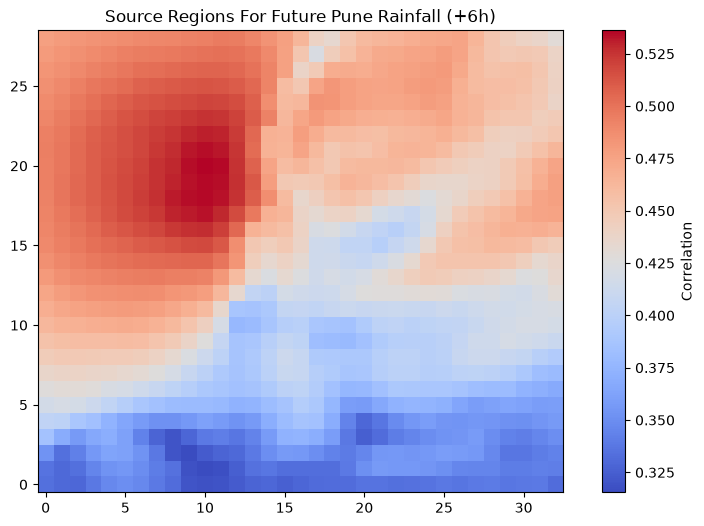

In [17]:
# =====================================================
# TEST 7 : SOURCE REGION MAPPING
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

lead = 6

rain_region = y_small.mean(axis=(1,2))

source_corr = np.zeros(
    (
        X.shape[1],
        X.shape[2]
    )
)

for i in range(X.shape[1]):

    for j in range(X.shape[2]):

        source_corr[i,j] = np.corrcoef(

            moisture_flux_mag[:-lead,i,j],

            rain_region[lead:]

        )[0,1]

plt.figure(figsize=(10,6))

plt.imshow(
    source_corr,
    origin='lower',
    cmap='coolwarm'
)

plt.colorbar(
    label="Correlation"
)

plt.title(
    "Source Regions For Future Pune Rainfall (+6h)"
)

plt.show()

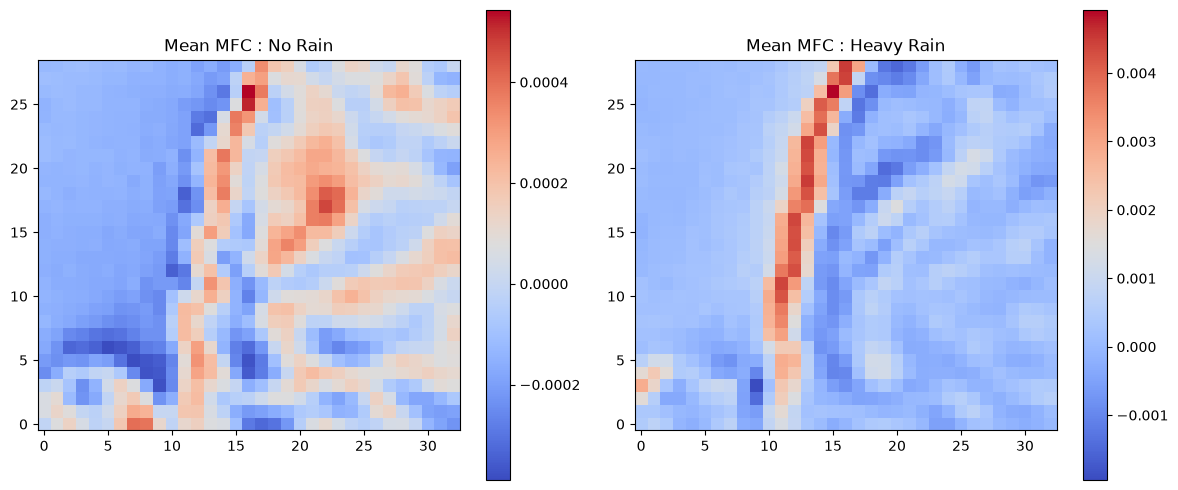

In [18]:
# =====================================================
# TEST 8 : MFC HOTSPOT ANALYSIS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

rain_region = y_small.mean(axis=(1,2))

low_thr = np.percentile(
    rain_region,
    25
)

high_thr = np.percentile(
    rain_region,
    95
)

norain_idx = np.where(
    rain_region <= low_thr
)[0]

heavyrain_idx = np.where(
    rain_region >= high_thr
)[0]

mfc_no_rain = (
    moisture_flux_convergence[norain_idx]
    .mean(axis=0)
)

mfc_heavy_rain = (
    moisture_flux_convergence[heavyrain_idx]
    .mean(axis=0)
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.imshow(
    mfc_no_rain,
    origin='lower',
    cmap='coolwarm'
)

plt.colorbar()

plt.title(
    "Mean MFC : No Rain"
)

plt.subplot(1,2,2)

plt.imshow(
    mfc_heavy_rain,
    origin='lower',
    cmap='coolwarm'
)

plt.colorbar()

plt.title(
    "Mean MFC : Heavy Rain"
)

plt.tight_layout()

plt.show()

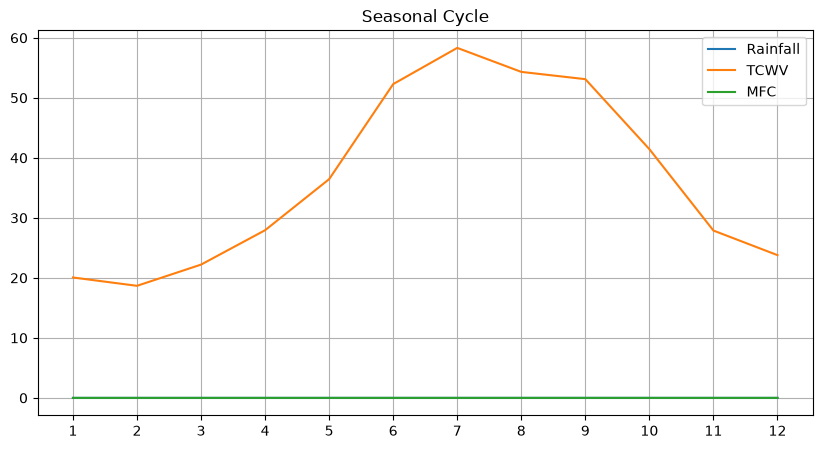

In [19]:
# =====================================================
# TEST 9 : SEASONAL ANALYSIS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

time_index = pd.date_range(
    start="2018-01-01",
    periods=len(y),
    freq="h"
)

monthly_rain = []
monthly_tcwv = []
monthly_mfc = []

for month in range(1,13):

    idx = (
        time_index.month == month
    )

    monthly_rain.append(
        y_small[idx].mean()
    )

    monthly_tcwv.append(
        tcwv[idx].mean()
    )

    monthly_mfc.append(
        moisture_flux_convergence[idx].mean()
    )

months = np.arange(1,13)

plt.figure(figsize=(10,5))

plt.plot(
    months,
    monthly_rain,
    label="Rainfall"
)

plt.plot(
    months,
    monthly_tcwv,
    label="TCWV"
)

plt.plot(
    months,
    monthly_mfc,
    label="MFC"
)

plt.xticks(months)

plt.grid(True)

plt.legend()

plt.title(
    "Seasonal Cycle"
)

plt.show()

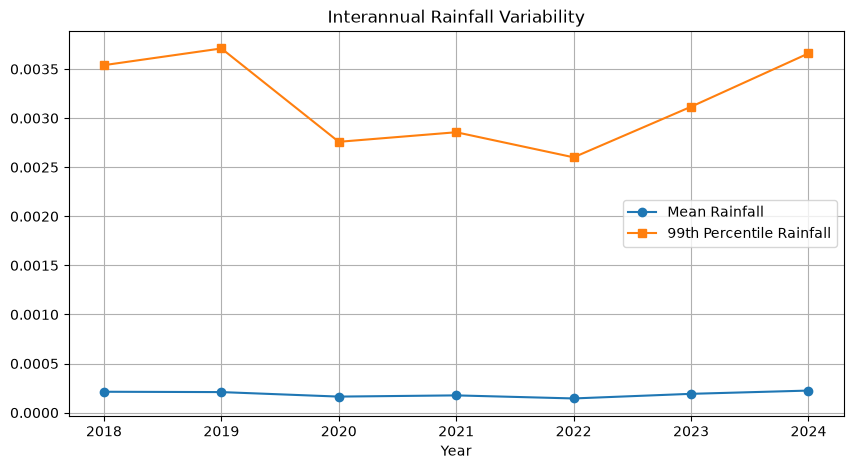

In [20]:
# =====================================================
# TEST 10 : INTERANNUAL ANALYSIS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

time_index = pd.date_range(
    start="2018-01-01",
    periods=len(y),
    freq="h"
)

years = sorted(
    np.unique(time_index.year)
)

annual_rain = []
annual_extreme = []

for year in years:

    idx = (
        time_index.year == year
    )

    annual_rain.append(

        y_small[idx]
        .mean()

    )

    annual_extreme.append(

        np.percentile(
            y_small[idx],
            99
        )

    )

plt.figure(figsize=(10,5))

plt.plot(
    years,
    annual_rain,
    marker='o',
    label='Mean Rainfall'
)

plt.plot(
    years,
    annual_extreme,
    marker='s',
    label='99th Percentile Rainfall'
)

plt.grid(True)

plt.legend()

plt.title(
    "Interannual Rainfall Variability"
)

plt.xlabel("Year")

plt.show()

In [21]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [23]:
class SpatialEncoder(nn.Module):

    def __init__(self, in_channels=20):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Linear(
            128,
            512
        )

    def forward(self, x):

        x = self.encoder(x)

        x = x.flatten(1)

        x = self.fc(x)

        return x

In [24]:
class TemporalTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(

            d_model=512,

            nhead=8,

            dim_feedforward=2048,

            dropout=0.1,

            batch_first=True

        )

        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=4
        )

    def forward(self, x):

        return self.transformer(x)

In [25]:
class RainVisionV1(nn.Module):

    def __init__(self):

        super().__init__()

        self.spatial_encoder = SpatialEncoder(
            in_channels=20
        )

        self.temporal_transformer = TemporalTransformer()

        self.rain_occurrence = nn.Sequential(

            nn.Linear(512,256),

            nn.ReLU(),

            nn.Linear(256,1)
        )

        self.rain_intensity = nn.Sequential(

            nn.Linear(512,256),

            nn.ReLU(),

            nn.Linear(256,64),

            nn.ReLU(),

            nn.Linear(64,1)
        )

    def forward(self, x):

        B,T,H,W,C = x.shape

        embeddings = []

        for t in range(T):

            frame = x[:,t]

            frame = frame.permute(
                0,3,1,2
            )

            emb = self.spatial_encoder(
                frame
            )

            embeddings.append(emb)

        embeddings = torch.stack(
            embeddings,
            dim=1
        )

        temporal = self.temporal_transformer(
            embeddings
        )

        last_state = temporal[:,-1]

        rain_prob = self.rain_occurrence(
            last_state
        )

        rain_intensity = self.rain_intensity(
            last_state
        )

        return rain_prob, rain_intensity

In [26]:
y_small = y[:, lat_mask, :]
y_small = y_small[:, :, lon_mask]

print(y_small.shape)

(61368, 3, 5)


In [29]:
HISTORY = 72
LEAD = 6

from torch.utils.data import Dataset

class RainDataset(Dataset):

    def __init__(
        self,
        X,
        rain_target,
        history=72,
        lead=6
    ):

        self.X = X.astype(np.float32)

        self.rain_target = rain_target.astype(
            np.float32
        )

        self.history = history
        self.lead = lead

        self.length = (
            len(X)
            - history
            - lead
        )

    def __len__(self):
        return self.length

    def __getitem__(self, idx):

        t = idx + self.history

        x = self.X[
            t-self.history:t
        ]

        future_rain = self.rain_target[
            t+self.lead
        ]

        occurrence = (
            1.0 if future_rain > 0.1
            else 0.0
        )

        return (
            torch.tensor(x),
            torch.tensor(occurrence),
            torch.tensor(
                future_rain,
                dtype=torch.float32
            )
        )

In [30]:
rain_target = y_small.mean(axis=(1,2))

dataset = RainDataset(
    X,
    rain_target,
    HISTORY,
    LEAD
)

print(
    "Samples:",
    len(dataset)
)

Samples: 61290


In [31]:
from torch.utils.data import random_split

train_size = int(
    0.8 * len(dataset)
)

val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

In [38]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

In [39]:
for batch in train_loader:

    x_batch, y_occ, y_int = batch

    print(
        x_batch.shape
    )

    print(
        y_occ.shape
    )

    print(
        y_int.shape
    )

    break

torch.Size([4, 72, 29, 33, 20])
torch.Size([4])
torch.Size([4])


In [42]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = RainVisionV1().to(device)

x_batch, y_occ, y_int = next(
    iter(train_loader)
)

x_batch = x_batch.to(device)

with torch.no_grad():

    pred_occ, pred_int = model(
        x_batch
    )

print(pred_occ.shape)
print(pred_int.shape)

torch.Size([4, 1])
torch.Size([4, 1])


In [43]:
bce_loss = nn.BCEWithLogitsLoss()

mse_loss = nn.MSELoss()

In [44]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

In [45]:
def evaluate(
    model,
    loader,
    device
):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for (
            x_batch,
            y_occ,
            y_int
        ) in loader:

            x_batch = x_batch.to(device)

            y_occ = (
                y_occ
                .unsqueeze(1)
                .to(device)
            )

            y_int = (
                y_int
                .unsqueeze(1)
                .to(device)
            )

            pred_occ, pred_int = model(
                x_batch
            )

            loss_occ = bce_loss(
                pred_occ,
                y_occ
            )

            rain_mask = (
                y_occ > 0.5
            ).float()

            loss_int = mse_loss(
                pred_int * rain_mask,
                y_int * rain_mask
            )

            loss = (
                loss_occ
                + loss_int
            )

            total_loss += loss.item()

    return (
        total_loss
        / len(loader)
    )

In [46]:
EPOCHS = 30

best_val_loss = np.inf

train_losses = []
val_losses = []

In [ ]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for (
        x_batch,
        y_occ,
        y_int
    ) in train_loader:

        x_batch = x_batch.to(device)

        y_occ = (
            y_occ
            .unsqueeze(1)
            .to(device)
        )

        y_int = (
            y_int
            .unsqueeze(1)
            .to(device)
        )

        optimizer.zero_grad()

        pred_occ, pred_int = model(
            x_batch
        )

        loss_occ = bce_loss(
            pred_occ,
            y_occ
        )

        rain_mask = (
            y_occ > 0.5
        ).float()

        loss_int = mse_loss(
            pred_int * rain_mask,
            y_int * rain_mask
        )

        loss = (
            loss_occ
            + loss_int
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = (
        running_loss
        / len(train_loader)
    )

    val_loss = evaluate(
        model,
        val_loader,
        device
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch+1:02d} "
        f"| Train={train_loss:.4f} "
        f"| Val={val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "RainVisionV1_best.pth"
        )

        print(
            "Best model saved."
        )

In [1]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

NameError: name 'torch' is not defined